<a href="https://colab.research.google.com/github/annabashlakova/ECON3916-Statistical-Machine-Learning/blob/main/Lab_4_Descriptive_Statistics_%26_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


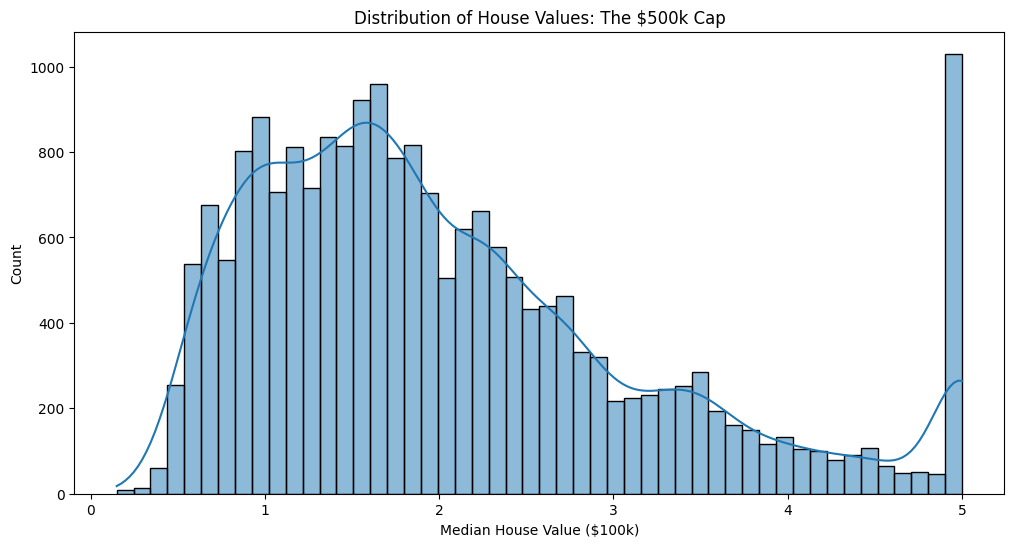

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Ingest Data
data = fetch_california_housing(as_frame=True)
df = data.frame

# 2. Inspect the "Ceiling Effect"
print(df['MedHouseVal']. describe())

plt.figure(figsize=(12, 6))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Distribution of House Values: The $500k Cap')
plt.xlabel("Median House Value ($100k)")
plt.show()

In [ ]:
def flag_outliers_iqr(df, column):

  # Calculate Quartiles
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  # Define the "Tukey Fence"
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Return Boolean Mask
  return (df[column] < lower_bound) | (df[column] > upper_bound)

  # Apply to Median Income
  df['outlier_iqr'] = flag_outliers_iqr(df, 'MedInc')

  print(f"Manual OUtliers Detected: {df['outlier_iqr']. sum()}")
  print("These are primarily the 'Wealthy' districts")

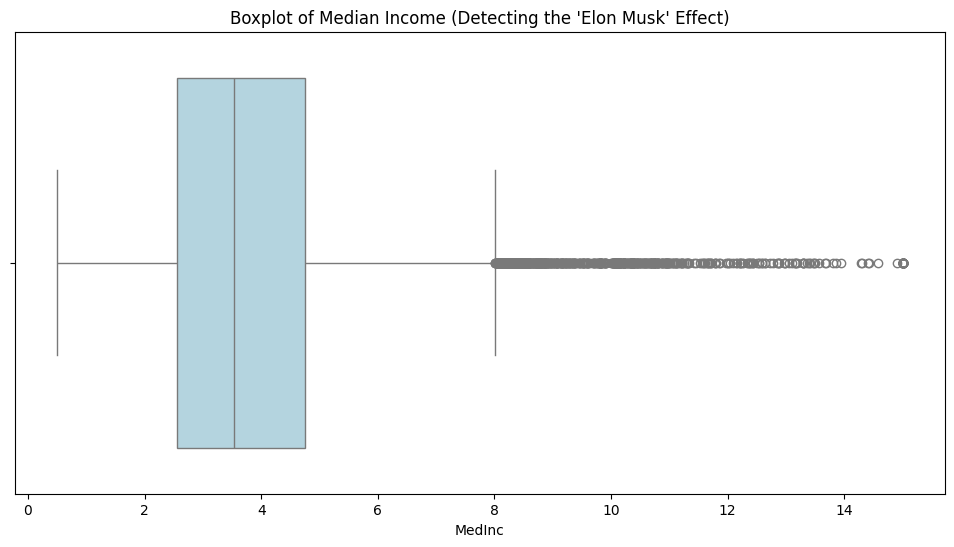

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['MedInc'], color = 'lightblue')
plt.title("Boxplot of Median Income (Detecting the 'Elon Musk' Effect)")
plt.show()

In [ ]:
# initialize the model
# contamination=0.05: we estimate that ~5% of the data is anomalous
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Features to analyze (income, house, age, average rooms)
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']

# Fit and Predict (-1 = Outlier, 1 = Normal)
preds = iso_forest.fit_predict(df[features])

# Map to boolean (True if outlier)
df['outlier_iso'] = preds == -1

print(f"Isolation Forest Outliers Detected: {df['outlier_iso'].sum()}")

Isolation Forest Outliers Detected: 1032


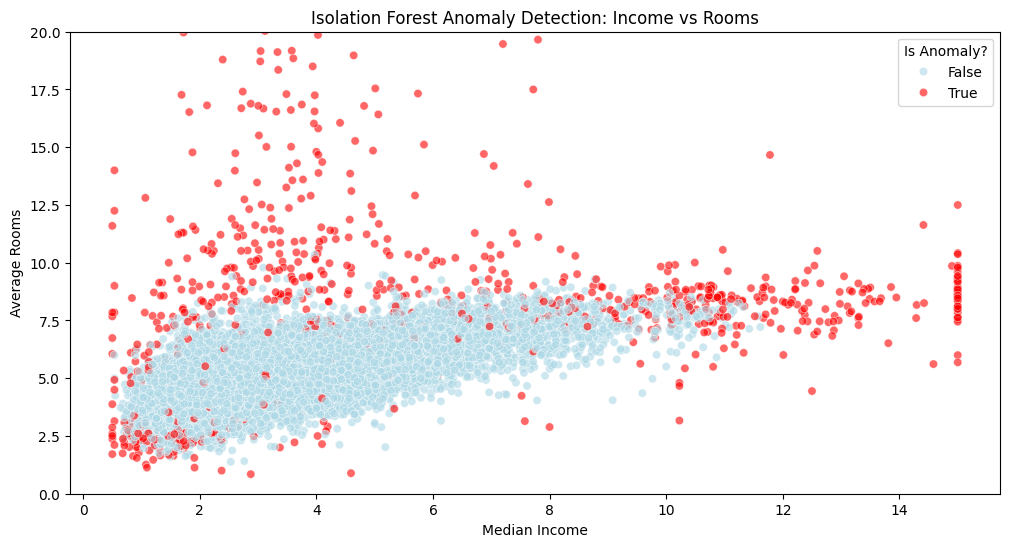

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure (figsize=(12, 6))

# Plot points flagged by Isolation Forest
sns.scatterplot (
    data = df,
    x = 'MedInc',
    y = 'AveRooms',
    hue = 'outlier_iso',
    palette={True: 'red', False: 'lightblue'},
    alpha = 0.6
)

plt.title("Isolation Forest Anomaly Detection: Income vs Rooms")
plt.xlabel("Median Income")
plt.ylabel("Average Rooms")
plt.ylim(0,20)  # Zoomed in to ignore extreme errors
plt.legend(title = 'Is Anomaly?')
plt.show()

Normal observations: 19608
Outlier observations: 1032

COMPARATIVE STATISTICS: NORMAL vs OUTLIER
Group               Normal  Outlier
MedInc_Mean         3.7696   5.7908
MedInc_Median       3.5156   4.2570
MedInc_Std          1.6406   4.1454
MedInc_MAD          1.0316   2.4919
MedHouseVal_Mean    2.0370   2.6682
MedHouseVal_Median  1.7890   2.0570
MedHouseVal_Std     1.1141   1.6348
MedHouseVal_MAD     0.6740   1.1030

INEQUALITY WEDGE ANALYSIS (OUTLIERS ONLY)
             Metric     Mean  Median  Inequality_Wedge  Std_Dev    MAD
    MedInc (Income) 5.790782 4.25695          1.533832 4.145354 2.4919
MedHouseVal (Value) 2.668172 2.05700          0.611172 1.634770 1.1030

* Positive wedge = right-skewed distribution (mean pulled by high values)


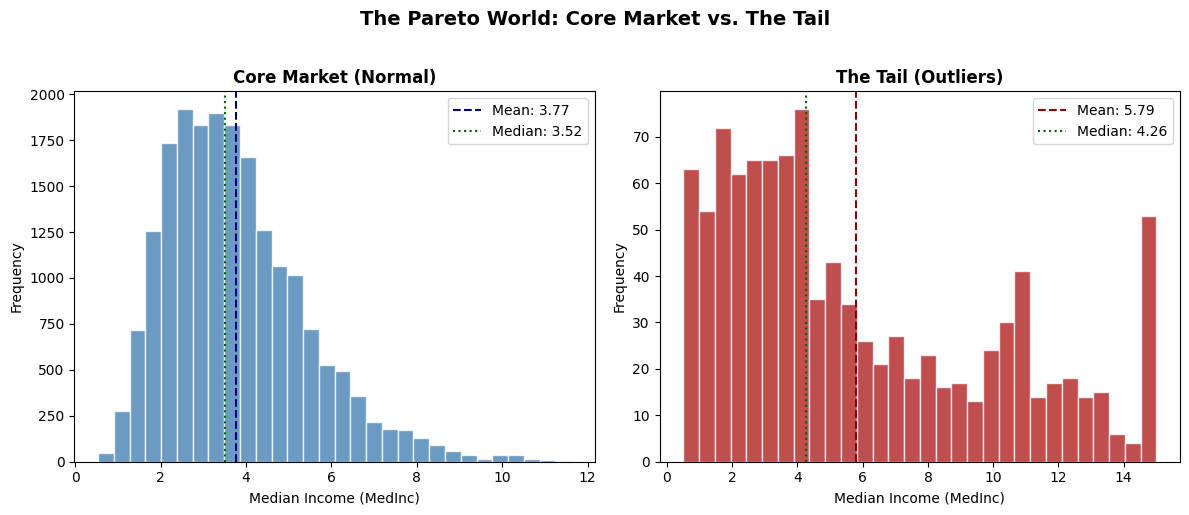

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. SPLIT DATA INTO NORMAL AND OUTLIER GROUPS

df_normal = df[df['outlier_iso'] == False].copy()
df_outlier = df[df['outlier_iso'] == True].copy()

print(f"Normal observations: {len(df_normal)}")
print(f"Outlier observations: {len(df_outlier)}\n")


# 2 & 3. CALCULATE STATISTICS FOR BOTH GROUPS

def calculate_stats(data, group_name):
    """Calculate Mean, Median, Std Dev, and MAD for key columns."""
    stats = {
        'Group': group_name,
        'MedInc_Mean': data['MedInc'].mean(),
        'MedInc_Median': data['MedInc'].median(),
        'MedInc_Std': data['MedInc'].std(),
        'MedInc_MAD': (data['MedInc'] - data['MedInc'].median()).abs().median(),
        'MedHouseVal_Mean': data['MedHouseVal'].mean(),
        'MedHouseVal_Median': data['MedHouseVal'].median(),
        'MedHouseVal_Std': data['MedHouseVal'].std(),
        'MedHouseVal_MAD': (data['MedHouseVal'] - data['MedHouseVal'].median()).abs().median(),
    }
    return stats

stats_normal = calculate_stats(df_normal, 'Normal')
stats_outlier = calculate_stats(df_outlier, 'Outlier')

# Create comparison DataFrame
comparison_df = pd.DataFrame([stats_normal, stats_outlier]).set_index('Group')
print("=" * 60)
print("COMPARATIVE STATISTICS: NORMAL vs OUTLIER")
print("=" * 60)
print(comparison_df.T.round(4))


# 4. INEQUALITY WEDGE SUMMARY (OUTLIERS)

inequality_wedge = pd.DataFrame({
    'Metric': ['MedInc (Income)', 'MedHouseVal (Value)'],
    'Mean': [stats_outlier['MedInc_Mean'], stats_outlier['MedHouseVal_Mean']],
    'Median': [stats_outlier['MedInc_Median'], stats_outlier['MedHouseVal_Median']],
    'Inequality_Wedge': [
        stats_outlier['MedInc_Mean'] - stats_outlier['MedInc_Median'],
        stats_outlier['MedHouseVal_Mean'] - stats_outlier['MedHouseVal_Median']
    ],
    'Std_Dev': [stats_outlier['MedInc_Std'], stats_outlier['MedHouseVal_Std']],
    'MAD': [stats_outlier['MedInc_MAD'], stats_outlier['MedHouseVal_MAD']]
})

print("\n" + "=" * 60)
print("INEQUALITY WEDGE ANALYSIS (OUTLIERS ONLY)")
print("=" * 60)
print(inequality_wedge.to_string(index=False))
print("\n* Positive wedge = right-skewed distribution (mean pulled by high values)")


# 5. VISUALIZATION: HISTOGRAM COMPARISON

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Normal points
axes[0].hist(df_normal['MedInc'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(stats_normal['MedInc_Mean'], color='navy', linestyle='--', label=f"Mean: {stats_normal['MedInc_Mean']:.2f}")
axes[0].axvline(stats_normal['MedInc_Median'], color='darkgreen', linestyle=':', label=f"Median: {stats_normal['MedInc_Median']:.2f}")
axes[0].set_xlabel('Median Income (MedInc)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Core Market (Normal)', fontsize=12, fontweight='bold')
axes[0].legend()

# Right: Outlier points
axes[1].hist(df_outlier['MedInc'], bins=30, color='firebrick', edgecolor='white', alpha=0.8)
axes[1].axvline(stats_outlier['MedInc_Mean'], color='darkred', linestyle='--', label=f"Mean: {stats_outlier['MedInc_Mean']:.2f}")
axes[1].axvline(stats_outlier['MedInc_Median'], color='darkgreen', linestyle=':', label=f"Median: {stats_outlier['MedInc_Median']:.2f}")
axes[1].set_xlabel('Median Income (MedInc)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('The Tail (Outliers)', fontsize=12, fontweight='bold')
axes[1].legend()

fig.suptitle('The Pareto World: Core Market vs. The Tail', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()